# 1. data generate

In [7]:
import cv2

input_video_path = 'test_vid/230411BVK107.mp4'
output_video_path = 'output_video.mp4'
output_image_path = 'output_image.png'

video_capture = cv2.VideoCapture(input_video_path)

if not video_capture.isOpened():
    print("Error: Could not open video.")
    exit()

# 16 frame
frames = []
frame_count = 0

while frame_count < 16:
    ret, frame = video_capture.read()
    if not ret:
        break
    frames.append(frame)
    frame_count += 1

if frames:
    height, width, layers = frames[7].shape
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    out = cv2.VideoWriter(output_video_path, fourcc, 30.0, (width, height))

    for frame in frames:
        out.write(frame)

    out.release()

if frames:
    cv2.imwrite(output_image_path, frames[7])

video_capture.release()
cv2.destroyAllWindows()

print("Video and image saved successfully.")

Video and image saved successfully.


# 2. MODEL


In [2]:
from __future__ import division, absolute_import
import warnings
import torch
from torch import nn
from torch.nn import functional as F

__all__ = [
    'osnet_x1_0', 'osnet_x0_75', 'osnet_x0_5', 'osnet_x0_25', 'osnet_ibn_x1_0', 'osnet_x0_25_endocv'
]

pretrained_urls = {
    'osnet_x1_0':
    'https://drive.google.com/uc?id=1LaG1EJpHrxdAxKnSCJ_i0u-nbxSAeiFY',
    'osnet_x0_75':
    'https://drive.google.com/uc?id=1uwA9fElHOk3ZogwbeY5GkLI6QPTX70Hq',
    'osnet_x0_5':
    'https://drive.google.com/uc?id=16DGLbZukvVYgINws8u8deSaOqjybZ83i',
    'osnet_x0_25':
    'https://drive.google.com/uc?id=1rb8UN5ZzPKRc_xvtHlyDh-cSz88YX9hs',
    'osnet_ibn_x1_0':
    'https://drive.google.com/uc?id=1sr90V6irlYYDd4_4ISU2iruoRG8J__6l',
    'osnet_x0_25_endocv':
    'https://drive.google.com/uc?id=1W8mz6skAUmg33zMVpWn6woJym7xGygjh'
}


##########
# Basic layers
##########
class ConvLayer(nn.Module):
    """Convolution layer (conv + bn + relu)."""

    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size,
        stride=1,
        padding=0,
        groups=1,
        IN=False
    ):
        super(ConvLayer, self).__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size,
            stride=stride,
            padding=padding,
            bias=False,
            groups=groups
        )
        if IN:
            self.bn = nn.InstanceNorm2d(out_channels, affine=True)
        else:
            self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class Conv1x1(nn.Module):
    """1x1 convolution + bn + relu."""

    def __init__(self, in_channels, out_channels, stride=1, groups=1):
        super(Conv1x1, self).__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            1,
            stride=stride,
            padding=0,
            bias=False,
            groups=groups
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class Conv1x1Linear(nn.Module):
    """1x1 convolution + bn (w/o non-linearity)."""

    def __init__(self, in_channels, out_channels, stride=1):
        super(Conv1x1Linear, self).__init__()
        self.conv = nn.Conv2d(
            in_channels, out_channels, 1, stride=stride, padding=0, bias=False
        )
        self.bn = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        return x


class Conv3x3(nn.Module):
    """3x3 convolution + bn + relu."""

    def __init__(self, in_channels, out_channels, stride=1, groups=1):
        super(Conv3x3, self).__init__()
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            3,
            stride=stride,
            padding=1,
            bias=False,
            groups=groups
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


class LightConv3x3(nn.Module):
    """Lightweight 3x3 convolution.

    1x1 (linear) + dw 3x3 (nonlinear).
    """

    def __init__(self, in_channels, out_channels):
        super(LightConv3x3, self).__init__()
        self.conv1 = nn.Conv2d(
            in_channels, out_channels, 1, stride=1, padding=0, bias=False
        )
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            3,
            stride=1,
            padding=1,
            bias=False,
            groups=out_channels
        )
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn(x)
        x = self.relu(x)
        return x


##########
# Building blocks for omni-scale feature learning
##########
class ChannelGate(nn.Module):
    """A mini-network that generates channel-wise gates conditioned on input tensor."""

    def __init__(
        self,
        in_channels,
        num_gates=None,
        return_gates=False,
        gate_activation='sigmoid',
        reduction=16,
        layer_norm=False
    ):
        super(ChannelGate, self).__init__()
        if num_gates is None:
            num_gates = in_channels
        self.return_gates = return_gates
        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(
            in_channels,
            in_channels // reduction,
            kernel_size=1,
            bias=True,
            padding=0
        )
        self.norm1 = None
        if layer_norm:
            self.norm1 = nn.LayerNorm((in_channels // reduction, 1, 1))
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Conv2d(
            in_channels // reduction,
            num_gates,
            kernel_size=1,
            bias=True,
            padding=0
        )
        if gate_activation == 'sigmoid':
            self.gate_activation = nn.Sigmoid()
        elif gate_activation == 'relu':
            self.gate_activation = nn.ReLU(inplace=True)
        elif gate_activation == 'linear':
            self.gate_activation = None
        else:
            raise RuntimeError(
                "Unknown gate activation: {}".format(gate_activation)
            )

    def forward(self, x):
        input = x
        x = self.global_avgpool(x)
        x = self.fc1(x)
        if self.norm1 is not None:
            x = self.norm1(x)
        x = self.relu(x)
        x = self.fc2(x)
        if self.gate_activation is not None:
            x = self.gate_activation(x)
        if self.return_gates:
            return x
        return input * x


class OSBlock(nn.Module):
    """Omni-scale feature learning block."""

    def __init__(
        self,
        in_channels,
        out_channels,
        IN=False,
        bottleneck_reduction=4,
        **kwargs
    ):
        super(OSBlock, self).__init__()
        mid_channels = out_channels // bottleneck_reduction
        self.conv1 = Conv1x1(in_channels, mid_channels)
        self.conv2a = LightConv3x3(mid_channels, mid_channels)
        self.conv2b = nn.Sequential(
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
        )
        self.conv2c = nn.Sequential(
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
        )
        self.conv2d = nn.Sequential(
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
            LightConv3x3(mid_channels, mid_channels),
        )
        self.gate = ChannelGate(mid_channels)
        self.conv3 = Conv1x1Linear(mid_channels, out_channels)
        self.downsample = None
        if in_channels != out_channels:
            self.downsample = Conv1x1Linear(in_channels, out_channels)
        self.IN = None
        if IN:
            self.IN = nn.InstanceNorm2d(out_channels, affine=True)

    def forward(self, x):
        identity = x
        x1 = self.conv1(x)
        x2a = self.conv2a(x1)
        x2b = self.conv2b(x1)
        x2c = self.conv2c(x1)
        x2d = self.conv2d(x1)
        x2 = self.gate(x2a) + self.gate(x2b) + self.gate(x2c) + self.gate(x2d)
        x3 = self.conv3(x2)
        if self.downsample is not None:
            identity = self.downsample(identity)
        out = x3 + identity
        if self.IN is not None:
            out = self.IN(out)
        return F.relu(out)


##########
# Network architecture
##########
class OSNet(nn.Module):
    """Omni-Scale Network.

    Reference:
        - Zhou et al. Omni-Scale Feature Learning for Person Re-Identification. ICCV, 2019.
        - Zhou et al. Learning Generalisable Omni-Scale Representations
          for Person Re-Identification. TPAMI, 2021.
    """

    def __init__(
        self,
        num_classes,
        blocks,
        layers,
        channels,
        feature_dim=512,
        loss='softmax',
        IN=False,
        **kwargs
    ):
        super(OSNet, self).__init__()
        num_blocks = len(blocks)
        assert num_blocks == len(layers)
        assert num_blocks == len(channels) - 1
        self.loss = loss
        self.feature_dim = feature_dim

        # convolutional backbone
        self.conv1 = ConvLayer(3, channels[0], 7, stride=2, padding=3, IN=IN)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.conv2 = self._make_layer(
            blocks[0],
            layers[0],
            channels[0],
            channels[1],
            reduce_spatial_size=True,
            IN=IN
        )
        self.conv3 = self._make_layer(
            blocks[1],
            layers[1],
            channels[1],
            channels[2],
            reduce_spatial_size=True
        )
        self.conv4 = self._make_layer(
            blocks[2],
            layers[2],
            channels[2],
            channels[3],
            reduce_spatial_size=False
        )
        self.conv5 = Conv1x1(channels[3], channels[3])
        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        # fully connected layer
        self.fc = self._construct_fc_layer(
            self.feature_dim, channels[3], dropout_p=None
        )
        # identity classification layer
        self.classifier = nn.Linear(self.feature_dim, num_classes)

        self._init_params()

    def _make_layer(
        self,
        block,
        layer,
        in_channels,
        out_channels,
        reduce_spatial_size,
        IN=False
    ):
        layers = []

        layers.append(block(in_channels, out_channels, IN=IN))
        for i in range(1, layer):
            layers.append(block(out_channels, out_channels, IN=IN))

        if reduce_spatial_size:
            layers.append(
                nn.Sequential(
                    Conv1x1(out_channels, out_channels),
                    nn.AvgPool2d(2, stride=2)
                )
            )

        return nn.Sequential(*layers)

    def _construct_fc_layer(self, fc_dims, input_dim, dropout_p=None):
        if fc_dims is None or fc_dims < 0:
            self.feature_dim = input_dim
            return None

        if isinstance(fc_dims, int):
            fc_dims = [fc_dims]

        layers = []
        for dim in fc_dims:
            layers.append(nn.Linear(input_dim, dim))
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.ReLU(inplace=True))
            if dropout_p is not None:
                layers.append(nn.Dropout(p=dropout_p))
            input_dim = dim

        self.feature_dim = fc_dims[-1]

        return nn.Sequential(*layers)

    def _init_params(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight, mode='fan_out', nonlinearity='relu'
                )
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.BatchNorm1d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def featuremaps(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)
        return x

    def forward(self, x, return_featuremaps=False):
        x = self.featuremaps(x)
        if return_featuremaps:
            return x
        v = self.global_avgpool(x)
        v = v.view(v.size(0), -1)
        if self.fc is not None:
            v = self.fc(v)
        if not self.training:
            return v
        y = self.classifier(v)
        if self.loss == 'softmax':
            return y
        elif self.loss == 'triplet':
            return y, v
        else:
            raise KeyError("Unsupported loss: {}".format(self.loss))


def init_pretrained_weights(model, key=''):
    """Initializes model with pretrained weights.

    Layers that don't match with pretrained layers in name or size are kept unchanged.
    """
    import os
    import errno
    import gdown
    from collections import OrderedDict

    def _get_torch_home():
        ENV_TORCH_HOME = 'TORCH_HOME'
        ENV_XDG_CACHE_HOME = 'XDG_CACHE_HOME'
        DEFAULT_CACHE_DIR = '~/.cache'
        torch_home = os.path.expanduser(
            os.getenv(
                ENV_TORCH_HOME,
                os.path.join(
                    os.getenv(ENV_XDG_CACHE_HOME, DEFAULT_CACHE_DIR), 'torch'
                )
            )
        )
        return torch_home

    torch_home = _get_torch_home()
    model_dir = os.path.join(torch_home, 'checkpoints')
    try:
        os.makedirs(model_dir)
    except OSError as e:
        if e.errno == errno.EEXIST:
            # Directory already exists, ignore.
            pass
        else:
            # Unexpected OSError, re-raise.
            raise
    filename = key + '_imagenet.pth'
    cached_file = os.path.join(model_dir, filename)

    if not os.path.exists(cached_file):
      if key == 'osnet_x0_25_endocv':
        filename = key + '.pth'
        cached_file = os.path.join(model_dir, filename)
        gdown.download(pretrained_urls[key], cached_file, quiet=False)
      else:
        gdown.download(pretrained_urls[key], cached_file, quiet=False)

    state_dict = torch.load(cached_file)
    model_dict = model.state_dict()
    new_state_dict = OrderedDict()
    matched_layers, discarded_layers = [], []

    for k, v in state_dict.items():
        if k.startswith('module.'):
            k = k[7:] # discard module.

        if k in model_dict and model_dict[k].size() == v.size():
            new_state_dict[k] = v
            matched_layers.append(k)
        else:
            discarded_layers.append(k)

    model_dict.update(new_state_dict)
    model.load_state_dict(model_dict)

    if len(matched_layers) == 0:
        warnings.warn(
            'The pretrained weights from "{}" cannot be loaded, '
            'please check the key names manually '
            '(** ignored and continue **)'.format(cached_file)
        )
    else:
        print(
            'Successfully loaded imagenet pretrained weights from "{}"'.
            format(cached_file)
        )
        if len(discarded_layers) > 0:
            print(
                '** The following layers are discarded '
                'due to unmatched keys or layer size: {}'.
                format(discarded_layers)
            )


##########
# Instantiation
##########
def osnet_x1_0(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # standard size (width x1.0)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[64, 256, 384, 512],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x1_0')
    return model


def osnet_x0_75(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # medium size (width x0.75)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[48, 192, 288, 384],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_75')
    return model


def osnet_x0_5(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # tiny size (width x0.5)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[32, 128, 192, 256],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_5')
    return model


def osnet_x0_25(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # very tiny size (width x0.25)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[16, 64, 96, 128],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_25')
    return model


def osnet_x0_25_endocv(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    # very tiny size (width x0.25)
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[16, 64, 96, 128],
        loss=loss,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_x0_25_endocv')
    return model


def osnet_ibn_x1_0(
    num_classes=1000, pretrained=True, loss='softmax', **kwargs
):
    # standard size (width x1.0) + IBN layer
    # Ref: Pan et al. Two at Once: Enhancing Learning and Generalization Capacities via IBN-Net. ECCV, 2018.
    model = OSNet(
        num_classes,
        blocks=[OSBlock, OSBlock, OSBlock],
        layers=[2, 2, 2],
        channels=[64, 256, 384, 512],
        loss=loss,
        IN=True,
        **kwargs
    )
    if pretrained:
        init_pretrained_weights(model, key='osnet_ibn_x1_0')
    return model

# 3. Ket hop

- Input: The code assumes a 5D input tensor [batch, channels, depth, height, width]. For single images, you’d need to stack or replicate the image across a temporal dimension.
- Spatial Alignment: F.interpolate ensures C3D and OSNet feature maps have the same spatial dimensions before concatenation.
- Performance: This hybrid model is heavier than standalone OSNet due to C3D’s 3D convolutions. Adjust C3D’s depth or channels if computational resources are limited.
- Fine-Tuning: If using pretrained OSNet weights, you may need to fine-tune the model since C3D and the merged layers start from scratch.

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# C3D Definition (slightly modified from your provided code)
class C3D(nn.Module):
    def __init__(self, in_channels=16):  # in_channels adjusted to match OSNet's conv2 output
        super(C3D, self).__init__()
        self.conv1 = nn.Conv3d(in_channels, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv2 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        self.conv3a = nn.Conv3d(128, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.conv3b = nn.Conv3d(256, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        self.conv4a = nn.Conv3d(256, 512, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.conv4b = nn.Conv3d(512, 512, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool4 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.pool1(h)
        h = self.relu(self.conv2(h))
        h = self.pool2(h)
        h = self.relu(self.conv3a(h))
        h = self.relu(self.conv3b(h))
        h = self.pool3(h)
        h = self.relu(self.conv4a(h))
        h = self.relu(self.conv4b(h))
        h = self.pool4(h)
        return h  # Output: [batch, 512, d', h', w']

# OSNet with C3D Integration
class OSNetWithC3D(nn.Module):
    def __init__(self, num_classes=1000, feature_dim=512, loss='softmax', **kwargs):
        super(OSNetWithC3D, self).__init__()
        # OSNet base configuration for osnet_x0_25
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.loss = loss

        # OSNet backbone components
        self.conv1 = ConvLayer(3, 16, 7, stride=2, padding=3)  # channels[0] = 16
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.conv2 = self._make_layer(OSBlock, 2, 16, 64, reduce_spatial_size=True)  # channels[1] = 64
        self.conv3 = self._make_layer(OSBlock, 2, 64, 96, reduce_spatial_size=True)  # channels[2] = 96
        
        # C3D branch
        self.c3d = C3D(in_channels=64)  # Input from conv2 output (64 channels)

        # Adjust conv4 to handle merged features (96 from OSNet + 512 from C3D)
        self.conv4 = self._make_layer(OSBlock, 2, 96 + 512, 128, reduce_spatial_size=False)  # channels[3] = 128
        self.conv5 = Conv1x1(128, 128)
        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = self._construct_fc_layer(feature_dim, 128, dropout_p=None)
        self.classifier = nn.Linear(feature_dim, num_classes)

        self._init_params()

    def _make_layer(self, block, layer, in_channels, out_channels, reduce_spatial_size, IN=False):
        layers = []
        layers.append(block(in_channels, out_channels, IN=IN))
        for i in range(1, layer):
            layers.append(block(out_channels, out_channels, IN=IN))
        if reduce_spatial_size:
            layers.append(nn.Sequential(Conv1x1(out_channels, out_channels), nn.AvgPool2d(2, stride=2)))
        return nn.Sequential(*layers)

    def _construct_fc_layer(self, fc_dims, input_dim, dropout_p=None):
        if fc_dims is None or fc_dims < 0:
            self.feature_dim = input_dim
            return None
        if isinstance(fc_dims, int):
            fc_dims = [fc_dims]
        layers = []
        for dim in fc_dims:
            layers.append(nn.Linear(input_dim, dim))
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.ReLU(inplace=True))
            if dropout_p is not None:
                layers.append(nn.Dropout(p=dropout_p))
            input_dim = dim
        self.feature_dim = fc_dims[-1]
        return nn.Sequential(*layers)

    def _init_params(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Conv3d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x, return_featuremaps=False):
        # Input: [batch, channels, depth, height, width] for video data
        batch, channels, depth, height, width = x.size()

        # Process each frame with OSNet early layers
        conv2_outputs = []
        for t in range(depth):
            frame = x[:, :, t, :, :]  # [batch, 3, height, width]
            h = self.conv1(frame)
            h = self.maxpool(h)
            h = self.conv2(h)  # [batch, 64, h', w']
            conv2_outputs.append(h)

        # Stack conv2 outputs along temporal dimension for C3D
        conv2_stack = torch.stack(conv2_outputs, dim=2)  # [batch, 64, depth, h', w']

        # C3D branch
        c3d_out = self.c3d(conv2_stack)  # [batch, 512, d', h'', w'']
        c3d_out = c3d_out.mean(dim=2)  # Temporal pooling: [batch, 512, h'', w'']

        # OSNet conv3 (using the last frame’s conv2 output as a representative)
        conv3_out = self.conv3(conv2_outputs[-1])  # [batch, 96, h'', w'']

        # Align spatial dimensions if necessary
        if c3d_out.size(2) != conv3_out.size(2) or c3d_out.size(3) != conv3_out.size(3):
            c3d_out = F.interpolate(c3d_out, size=conv3_out.size()[2:], mode='bilinear', align_corners=False)

        # Merge C3D and OSNet features
        merged = torch.cat([conv3_out, c3d_out], dim=1)  # [batch, 96 + 512, h'', w'']

        # Continue with OSNet remaining layers
        x = self.conv4(merged)
        x = self.conv5(x)

        if return_featuremaps:
            return x

        v = self.global_avgpool(x)
        v = v.view(v.size(0), -1)
        if self.fc is not None:
            v = self.fc(v)

        if not self.training:
            return v

        y = self.classifier(v)
        if self.loss == 'softmax':
            return y
        elif self.loss == 'triplet':
            return y, v
        else:
            raise KeyError(f"Unsupported loss: {self.loss}")

# Instantiate the model (osnet_x0_25 with C3D)
def osnet_x0_25_with_c3d(num_classes=1000, pretrained=True, loss='softmax', **kwargs):
    model = OSNetWithC3D(num_classes=num_classes, loss=loss, **kwargs)
    if pretrained:
        # Note: Pretrained weights for OSNet won’t directly apply to C3D parts
        init_pretrained_weights(model, key='osnet_x0_25')
    return model

# Example usage
if __name__ == "__main__":
    # Dummy video input: 2 samples, 3 channels, 16 frames, 256x256
    x = torch.randn(2, 3, 16, 256, 256)
    model = osnet_x0_25_with_c3d(num_classes=1000)
    output = model(x)
    print(output.shape)  # Should be [2, 1000]

/tmp/ipykernel_12464/757664991.py:489: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(cached_file)


Successfully loaded imagenet pretrained weights from "/home/ekai10/.cache/torch/checkpoints/osnet_x0_25_imagenet.pth"
** The following layers are discarded due to unmatched keys or layer size: ['conv4.0.conv1.conv.weight', 'conv4.0.downsample.conv.weight']
torch.Size([2, 1000])


In [5]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import cv2

# C3D Definition
class C3D(nn.Module):
    def __init__(self, in_channels=16):
        super(C3D, self).__init__()
        self.conv1 = nn.Conv3d(in_channels, 64, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool1 = nn.MaxPool3d(kernel_size=(1, 2, 2), stride=(1, 2, 2))
        self.conv2 = nn.Conv3d(64, 128, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool2 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        self.conv3a = nn.Conv3d(128, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.conv3b = nn.Conv3d(256, 256, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool3 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        self.conv4a = nn.Conv3d(256, 512, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.conv4b = nn.Conv3d(512, 512, kernel_size=(3, 3, 3), padding=(1, 1, 1))
        self.pool4 = nn.MaxPool3d(kernel_size=(2, 2, 2), stride=(2, 2, 2))
        self.relu = nn.ReLU()

    def forward(self, x):
        h = self.relu(self.conv1(x))
        h = self.pool1(h)
        h = self.relu(self.conv2(h))
        h = self.pool2(h)
        h = self.relu(self.conv3a(h))
        h = self.relu(self.conv3b(h))
        h = self.pool3(h)
        h = self.relu(self.conv4a(h))
        h = self.relu(self.conv4b(h))
        h = self.pool4(h)
        return h

# OSNet with C3D Integration
class OSNetWithC3D(nn.Module):
    def __init__(self, num_classes=1000, feature_dim=512, loss='softmax'):
        super(OSNetWithC3D, self).__init__()
        self.num_classes = num_classes
        self.feature_dim = feature_dim
        self.loss = loss

        # OSNet backbone components
        self.conv1 = ConvLayer(3, 16, 7, stride=2, padding=3)
        self.maxpool = nn.MaxPool2d(3, stride=2, padding=1)
        self.conv2 = self._make_layer(OSBlock, 2, 16, 64, reduce_spatial_size=True)
        self.conv3 = self._make_layer(OSBlock, 2, 64, 96, reduce_spatial_size=True)
        
        # C3D branch
        self.c3d = C3D(in_channels=64)

        # Adjust conv4 to handle merged features
        self.conv4 = self._make_layer(OSBlock, 2, 96 + 512, 128, reduce_spatial_size=False)
        self.conv5 = Conv1x1(128, 128)
        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = self._construct_fc_layer(feature_dim, 128, dropout_p=None)
        self.classifier = nn.Linear(feature_dim, num_classes)

        self._init_params()

    def _make_layer(self, block, layer, in_channels, out_channels, reduce_spatial_size, IN=False):
        layers = []
        layers.append(block(in_channels, out_channels, IN=IN))
        for i in range(1, layer):
            layers.append(block(out_channels, out_channels, IN=IN))
        if reduce_spatial_size:
            layers.append(nn.Sequential(Conv1x1(out_channels, out_channels), nn.AvgPool2d(2, stride=2)))
        return nn.Sequential(*layers)

    def _construct_fc_layer(self, fc_dims, input_dim, dropout_p=None):
        if fc_dims is None or fc_dims < 0:
            self.feature_dim = input_dim
            return None
        if isinstance(fc_dims, int):
            fc_dims = [fc_dims]
        layers = []
        for dim in fc_dims:
            layers.append(nn.Linear(input_dim, dim))
            layers.append(nn.BatchNorm1d(dim))
            layers.append(nn.ReLU(inplace=True))
            if dropout_p is not None:
                layers.append(nn.Dropout(p=dropout_p))
            input_dim = dim
        self.feature_dim = fc_dims[-1]
        return nn.Sequential(*layers)

    def _init_params(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Conv3d)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, (nn.BatchNorm2d, nn.BatchNorm1d)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01)
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)

    def forward(self, x):
        batch, channels, depth, height, width = x.size()

        # Process each frame with OSNet early layers
        conv2_outputs = []
        for t in range(depth):
            frame = x[:, :, t, :, :]
            h = self.conv1(frame)
            h = self.maxpool(h)
            h = self.conv2(h)
            conv2_outputs.append(h)

        # Stack for C3D
        conv2_stack = torch.stack(conv2_outputs, dim=2)
        c3d_out = self.c3d(conv2_stack)
        c3d_out = c3d_out.mean(dim=2)

        # OSNet continuation
        conv3_out = self.conv3(conv2_outputs[-1])
        if c3d_out.size(2) != conv3_out.size(2) or c3d_out.size(3) != conv3_out.size(3):
            c3d_out = F.interpolate(c3d_out, size=conv3_out.size()[2:], mode='bilinear', align_corners=False)

        merged = torch.cat([conv3_out, c3d_out], dim=1)
        x = self.conv4(merged)
        x = self.conv5(x)
        v = self.global_avgpool(x)
        v = v.view(v.size(0), -1)
        if self.fc is not None:
            v = self.fc(v)
        return v  # Feature vector [batch, feature_dim]

# Basic OSNet layers (placeholders from your previous code)
class ConvLayer(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, stride=1, padding=0, groups=1, IN=False):
        super(ConvLayer, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride, padding=padding, bias=False, groups=groups)
        self.bn = nn.BatchNorm2d(out_channels) if not IN else nn.InstanceNorm2d(out_channels, affine=True)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class Conv1x1(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, groups=1):
        super(Conv1x1, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, 1, stride=stride, padding=0, bias=False, groups=groups)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class LightConv3x3(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(LightConv3x3, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 1, stride=1, padding=0, bias=False)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, stride=1, padding=1, bias=False, groups=out_channels)
        self.bn = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.bn(x)
        x = self.relu(x)
        return x

class ChannelGate(nn.Module):
    def __init__(self, in_channels, num_gates=None, reduction=16, layer_norm=False):
        super(ChannelGate, self).__init__()
        num_gates = num_gates or in_channels
        self.global_avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc1 = nn.Conv2d(in_channels, in_channels // reduction, 1, bias=True)
        self.norm1 = nn.LayerNorm((in_channels // reduction, 1, 1)) if layer_norm else None
        self.relu = nn.ReLU(inplace=True)
        self.fc2 = nn.Conv2d(in_channels // reduction, num_gates, 1, bias=True)
        self.gate_activation = nn.Sigmoid()
    def forward(self, x):
        input = x
        x = self.global_avgpool(x)
        x = self.fc1(x)
        if self.norm1 is not None:
            x = self.norm1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.gate_activation(x)
        return input * x

class OSBlock(nn.Module):
    def __init__(self, in_channels, out_channels, IN=False, bottleneck_reduction=4):
        super(OSBlock, self).__init__()
        mid_channels = out_channels // bottleneck_reduction
        self.conv1 = Conv1x1(in_channels, mid_channels)
        self.conv2a = LightConv3x3(mid_channels, mid_channels)
        self.conv2b = nn.Sequential(LightConv3x3(mid_channels, mid_channels), LightConv3x3(mid_channels, mid_channels))
        self.conv2c = nn.Sequential(LightConv3x3(mid_channels, mid_channels), LightConv3x3(mid_channels, mid_channels), LightConv3x3(mid_channels, mid_channels))
        self.conv2d = nn.Sequential(LightConv3x3(mid_channels, mid_channels), LightConv3x3(mid_channels, mid_channels), LightConv3x3(mid_channels, mid_channels), LightConv3x3(mid_channels, mid_channels))
        self.gate = ChannelGate(mid_channels)
        self.conv3 = Conv1x1(mid_channels, out_channels)
        self.downsample = Conv1x1(in_channels, out_channels) if in_channels != out_channels else None
        self.IN = nn.InstanceNorm2d(out_channels, affine=True) if IN else None
    def forward(self, x):
        identity = x
        x1 = self.conv1(x)
        x2a = self.conv2a(x1)
        x2b = self.conv2b(x1)
        x2c = self.conv2c(x1)
        x2d = self.conv2d(x1)
        x2 = self.gate(x2a) + self.gate(x2b) + self.gate(x2c) + self.gate(x2d)
        x3 = self.conv3(x2)
        if self.downsample is not None:
            identity = self.downsample(identity)
        out = x3 + identity
        if self.IN is not None:
            out = self.IN(out)
        return F.relu(out)

# Function to process precomputed YOLO crops
def process_yolo_crops(crops, num_frames=16, crop_size=(256, 128)):
    """
    Process a sequence of precomputed YOLO crops to extract a ReID feature vector.
    
    Args:
        crops (list): List of numpy arrays, each of shape [H, W, 3] (RGB).
        num_frames (int): Number of frames to process.
        crop_size (tuple): Target size for resizing crops (height, width).
    
    Returns:
        torch.Tensor: Feature vector of shape [1, feature_dim].
    """
    # Load OSNetWithC3D model
    reid_model = OSNetWithC3D(num_classes=1000, feature_dim=512)
    reid_model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    reid_model.to(device)

    # Ensure we have exactly num_frames crops
    if len(crops) < num_frames:
        last_crop = crops[-1] if crops else np.zeros((*crop_size, 3), dtype=np.uint8)
        crops.extend([last_crop] * (num_frames - len(crops)))
    crops = crops[:num_frames]  # Truncate if too many

    # Preprocess crops: resize and convert to tensor
    processed_crops = []
    for crop in crops:
        # Resize to target size
        resized_crop = cv2.resize(crop, crop_size, interpolation=cv2.INTER_LINEAR)
        # Convert to tensor and normalize
        crop_tensor = torch.from_numpy(resized_crop.transpose(2, 0, 1)).float() / 255.0
        processed_crops.append(crop_tensor)

    # Stack into a batch tensor
    crops_tensor = torch.stack(processed_crops, dim=1)  # [1, 3, num_frames, H, W]
    crops_tensor = crops_tensor.unsqueeze(0).to(device)  # [1, 3, num_frames, H, W]

    # Extract feature vector
    with torch.no_grad():
        feature_vector = reid_model(crops_tensor)  # [1, 512]

    return feature_vector

# Example usage with dummy YOLO crops
if __name__ == "__main__":
    # Simulate precomputed YOLO crops (e.g., from 16 frames)
    dummy_crops = [np.random.randint(0, 255, (300, 150, 3), dtype=np.uint8) for _ in range(16)]  # Random crops
    
    # Process the crops
    feature_vector = process_yolo_crops(dummy_crops, num_frames=16, crop_size=(256, 128))
    print(f"Feature vector shape: {feature_vector.shape}")  # Should be [1, 512]
    print(f"Feature vector: {feature_vector}")

Feature vector shape: torch.Size([1, 512])
Feature vector: tensor([[0.0000e+00, 0.0000e+00, 6.2336e-04, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         2.1958e-02, 3.2663e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         2.4292e-02, 0.0000e+00, 0.0000e+00, 1.3775e-02, 0.0000e+00, 0.0000e+00,
         1.9115e-02, 0.0000e+00, 7.2917e-03, 4.5892e-02, 0.0000e+00, 1.1105e-02,
         0.0000e+00, 1.0016e-02, 0.0000e+00, 8.6715e-03, 0.0000e+00, 2.3079e-02,
         1.0365e-03, 0.0000e+00, 2.4708e-02, 0.0000e+00, 0.0000e+00, 3.5014e-02,
         4.1352e-03, 0.0000e+00, 0.0000e+00, 7.5627e-04, 1.4917e-02, 8.6555e-03,
         0.0000e+00, 7.4970e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         3.7514e-03, 0.0000e+00, 3.3562e-03, 8.3865e-03, 0.0000e+00, 0.0000e+00,
         7.3185e-03, 0.0000e+00, 0.0000e+00, 0.0000e+00, 2.1983e-03, 1.4761e-03,
         0.0000e+00, 1.2175e-02, 2.2929e-02, 1.4588e-02, 3.2761e-02, 0.0000e+00,
         3.0947e-03, 3.3167e-02, 1.2211e-02, 0.000

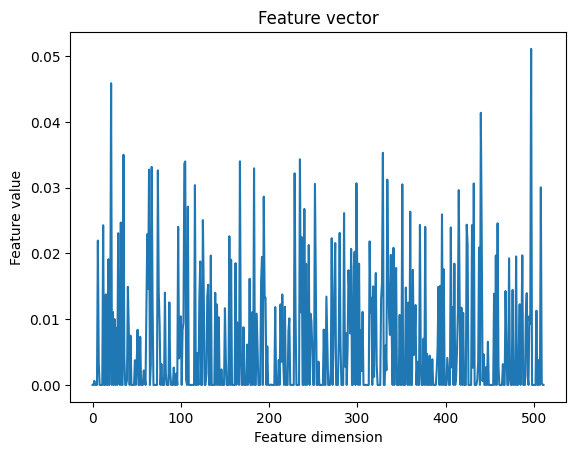

In [6]:
import matplotlib.pyplot as plt
plt.plot(feature_vector.squeeze().detach().cpu().numpy())
plt.title("Feature vector")
plt.xlabel("Feature dimension")
plt.ylabel("Feature value")
plt.show()

In [8]:
import torch
import cv2
import numpy as np

# Assuming the OSNetWithC3D and supporting classes (ConvLayer, etc.) are defined as in the previous code

# Function to process precomputed crops (from previous code)
def process_yolo_crops(crops, num_frames=16, crop_size=(256, 128)):
    reid_model = OSNetWithC3D(num_classes=1000, feature_dim=512)
    reid_model.eval()
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    reid_model.to(device)

    if len(crops) < num_frames:
        last_crop = crops[-1] if crops else np.zeros((*crop_size, 3), dtype=np.uint8)
        crops.extend([last_crop] * (num_frames - len(crops)))
    crops = crops[:num_frames]

    processed_crops = []
    for crop in crops:
        resized_crop = cv2.resize(crop, crop_size, interpolation=cv2.INTER_LINEAR)
        crop_tensor = torch.from_numpy(resized_crop.transpose(2, 0, 1)).float() / 255.0
        processed_crops.append(crop_tensor)

    crops_tensor = torch.stack(processed_crops, dim=1)
    crops_tensor = crops_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        feature_vector = reid_model(crops_tensor)
    return feature_vector

# Function to load video frames
def load_video_frames(video_path, num_frames=16):
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError("Error opening video file")

    frames = []
    frame_count = 0
    while cap.isOpened() and frame_count < num_frames:
        ret, frame = cap.read()
        if not ret:
            break
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        frames.append(frame_rgb)
        frame_count += 1

    cap.release()
    
    # Pad with last frame if needed
    if len(frames) < num_frames:
        last_frame = frames[-1] if frames else np.zeros((256, 128, 3), dtype=np.uint8)
        frames.extend([last_frame] * (num_frames - len(frames)))
    return frames[:num_frames]

# Scenario 1: Combine PNG and 15 video frames
def process_png_and_video_combined(png_path, video_path, num_frames=16):
    # Load PNG
    png_image = cv2.imread(png_path, cv2.IMREAD_COLOR)
    if png_image is None:
        raise ValueError("Error loading PNG image")
    png_rgb = cv2.cvtColor(png_image, cv2.COLOR_BGR2RGB)

    # Load video frames (get 15 frames since PNG takes 1 slot)
    video_frames = load_video_frames(video_path, num_frames - 1)  # 15 frames

    # Combine PNG and video frames
    crops = [png_rgb] + video_frames  # PNG as first frame, followed by 15 video frames

    # Process with ReID model
    feature_vector = process_yolo_crops(crops, num_frames=num_frames, crop_size=(256, 128))
    return feature_vector

# Scenario 2: Process PNG and video separately
def process_png_and_video_separately(png_path, video_path, num_frames=16):
    # Load PNG
    png_image = cv2.imread(png_path, cv2.IMREAD_COLOR)
    if png_image is None:
        raise ValueError("Error loading PNG image")
    png_rgb = cv2.cvtColor(png_image, cv2.COLOR_BGR2RGB)

    # Load all 16 video frames
    video_frames = load_video_frames(video_path, num_frames=num_frames)

    # Process PNG alone (repeat it to fill 16 frames)
    png_crops = [png_rgb] * num_frames  # Repeat PNG to match video length
    png_feature_vector = process_yolo_crops(png_crops, num_frames=num_frames, crop_size=(256, 128))

    # Process video frames
    video_feature_vector = process_yolo_crops(video_frames, num_frames=num_frames, crop_size=(256, 128))

    return png_feature_vector, video_feature_vector

# Example usage
if __name__ == "__main__":
    png_path = "output_image.png"  # Replace with your PNG file path
    video_path = "output_video.mp4"  # Replace with your video file path

    # Scenario 1: Combined PNG and 15 video frames
    print("Scenario 1: Combined PNG and Video")
    combined_feature_vector = process_png_and_video_combined(png_path, video_path, num_frames=16)
    print(f"Combined feature vector shape: {combined_feature_vector.shape}")  # [1, 512]
    print(f"Combined feature vector: {combined_feature_vector}")

    # Scenario 2: Separate PNG and Video
    print("\nScenario 2: Separate PNG and Video")
    png_feature_vector, video_feature_vector = process_png_and_video_separately(png_path, video_path, num_frames=16)
    print(f"PNG feature vector shape: {png_feature_vector.shape}")  # [1, 512]
    print(f"PNG feature vector: {png_feature_vector}")
    print(f"Video feature vector shape: {video_feature_vector.shape}")  # [1, 512]
    print(f"Video feature vector: {video_feature_vector}")

Scenario 1: Combined PNG and Video
Combined feature vector shape: torch.Size([1, 512])
Combined feature vector: tensor([[0.0000e+00, 0.0000e+00, 4.9240e-03, 2.4213e-02, 0.0000e+00, 2.2875e-02,
         2.1579e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 8.7980e-03,
         0.0000e+00, 2.6897e-02, 1.2270e-03, 0.0000e+00, 2.2508e-02, 0.0000e+00,
         1.0636e-02, 2.0750e-02, 0.0000e+00, 1.8028e-02, 3.2312e-02, 3.2262e-02,
         0.0000e+00, 1.8967e-02, 3.2796e-02, 3.7647e-02, 0.0000e+00, 3.6881e-03,
         1.0030e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00, 9.4714e-03,
         2.6385e-02, 3.0760e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 9.5575e-03,
         0.0000e+00, 8.8700e-03, 4.7668e-02, 7.1569e-03, 6.9850e-03, 4.5304e-03,
         0.0000e+00, 1.9017e-02, 0.0000e+00, 0.0000e+00, 0.0000e+00, 0.0000e+00,
         0.0000e+00, 3.9894e-03, 8.0717e-03, 0.0000e+00, 0.0000e+00, 2.1371e-02,
         0.0000e+00, 1.3382e-02, 0.0000e+00, 0.0000e+00, 7.1496e-03, 2.0348e-0

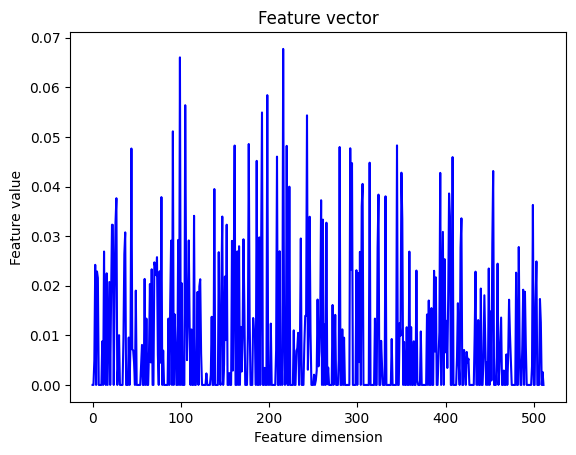

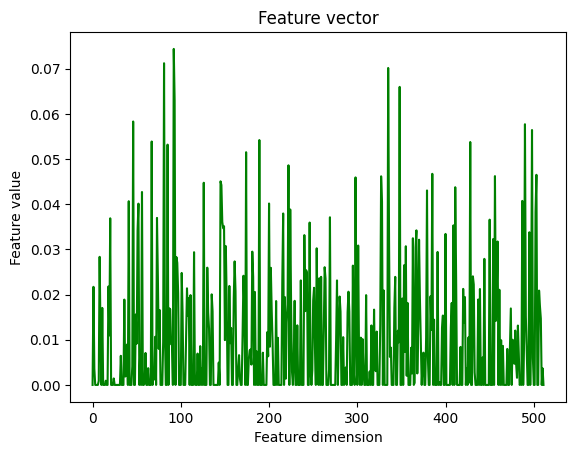

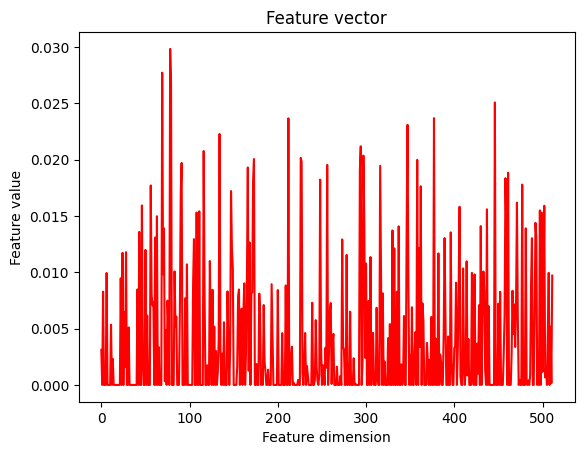

In [12]:
import matplotlib.pyplot as plt
plt.plot(combined_feature_vector.squeeze().detach().cpu().numpy(), color='b', label='Combined')
plt.title("Feature vector")
plt.xlabel("Feature dimension")
plt.ylabel("Feature value")
plt.show()

plt.plot(video_feature_vector.squeeze().detach().cpu().numpy(),  color='g', label='Video')
plt.title("Feature vector")
plt.xlabel("Feature dimension")
plt.ylabel("Feature value")

plt.show()

plt.plot(png_feature_vector.squeeze().detach().cpu().numpy(),  color='r', label='PNG')
plt.title("Feature vector")
plt.xlabel("Feature dimension")
plt.ylabel("Feature value")
plt.show()


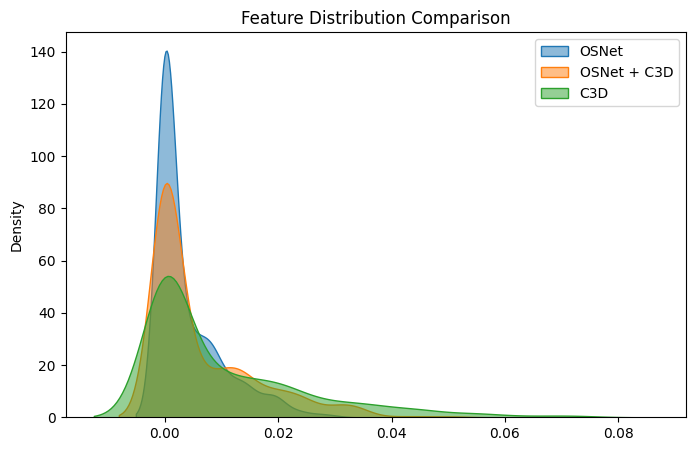

In [14]:
import seaborn as sns

# Chuyển về numpy
c3d_feat_np = video_feature_vector.squeeze().cpu().detach().numpy()
osnet_feat_np = png_feature_vector.squeeze().cpu().detach().numpy()
combined_feat_np = feature_vector.squeeze().cpu().detach().numpy()

plt.figure(figsize=(8, 5))
sns.kdeplot(osnet_feat_np, label="OSNet", fill=True, alpha=0.5)
sns.kdeplot(combined_feat_np, label="OSNet + C3D", fill=True, alpha=0.5)
sns.kdeplot(c3d_feat_np, label="C3D", fill=True, alpha=0.5)
plt.title("Feature Distribution Comparison")
plt.legend()
plt.show()

# zzzzz

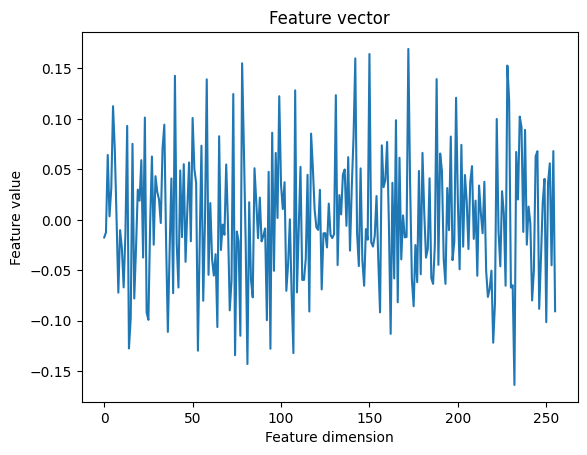

In [40]:
import matplotlib.pyplot as plt
plt.plot(feature_vector.squeeze().detach().cpu().numpy())
plt.title("Feature vector")
plt.xlabel("Feature dimension")
plt.ylabel("Feature value")
plt.show()

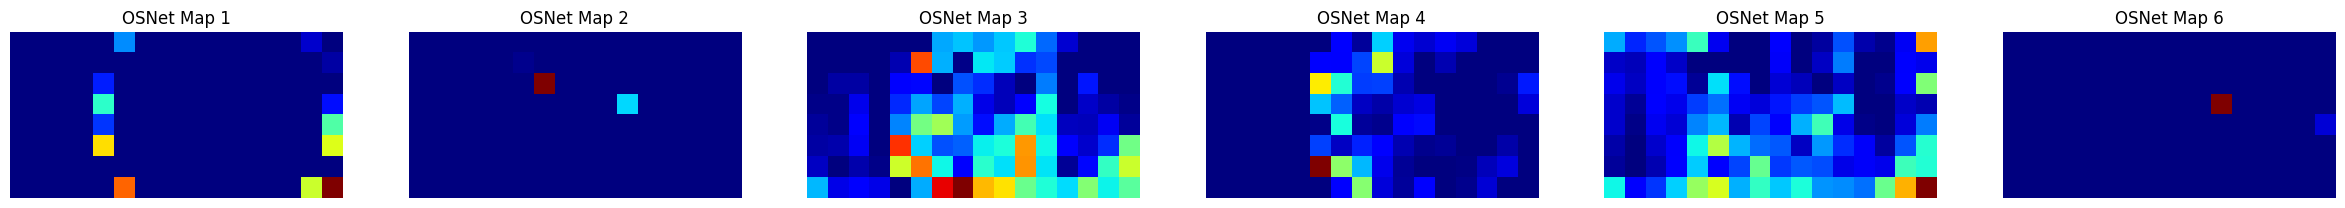

In [15]:
# OSNET
import matplotlib.pyplot as plt
import torch
import numpy as np

# First 6-channel feature map
num_channels = 6
fig, axes = plt.subplots(1, num_channels, figsize=(30, 10))

# Tensor to numpy
osnet_feat_map = osnet_feat_map.squeeze(0).cpu().detach().numpy()  # (C, H, W)

for i in range(num_channels):
    axes[i].imshow(osnet_feat_map[i], cmap='jet')
    axes[i].axis("off")
    axes[i].set_title(f"OSNet Map {i+1}")

plt.show()

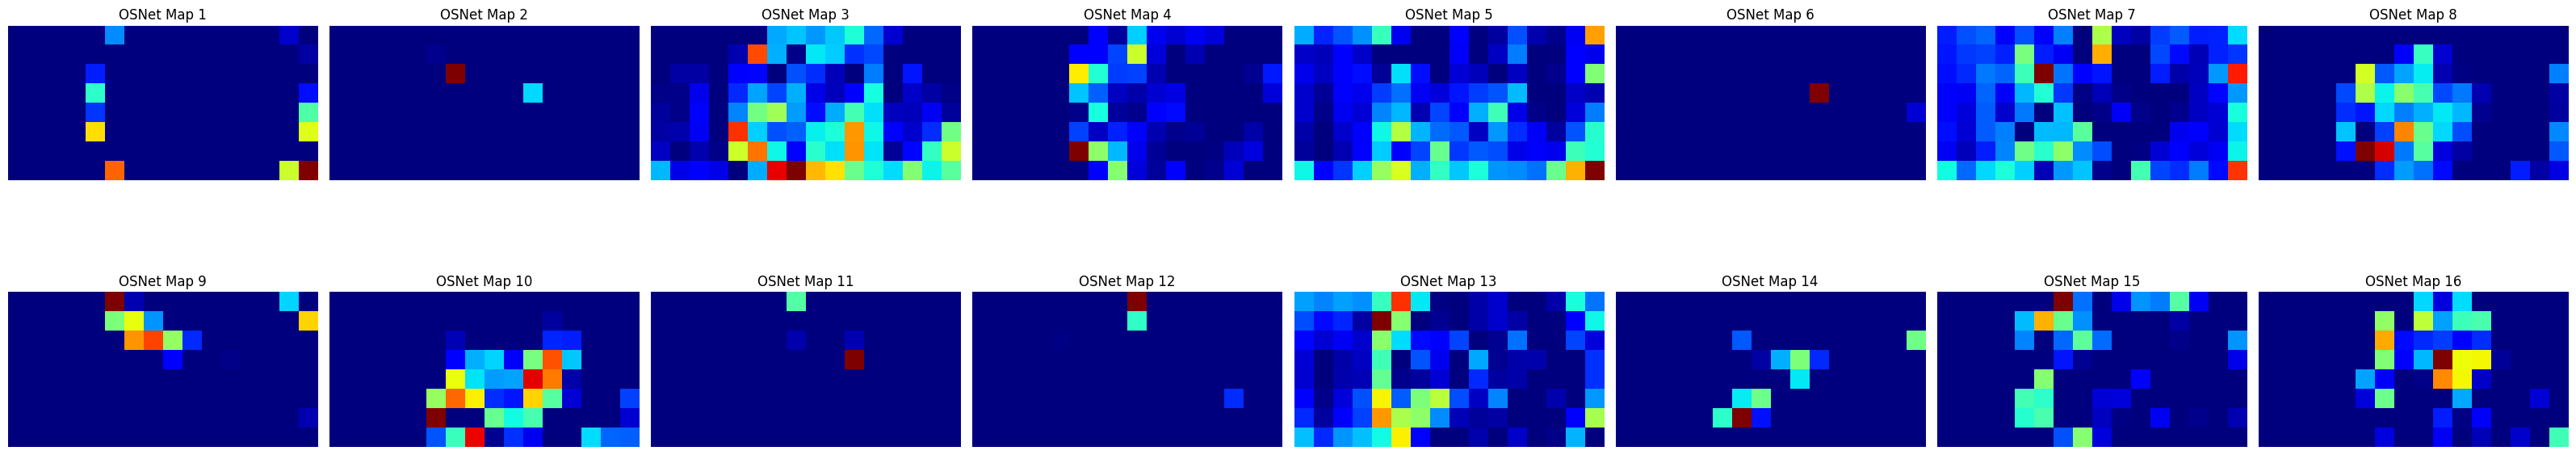

In [50]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# Giả sử osnet_feat_map đã được thu thập từ mô hình
# Số lượng kênh
num_channels = 16

# Tạo figure với 2 hàng, mỗi hàng 8 hình
fig, axes = plt.subplots(2, 8, figsize=(32, 8))

# Chuyển tensor thành numpy
osnet_feat_map = osnet_feat_map.squeeze(0).cpu().detach().numpy()  # (C, H, W)

# Vẽ feature map
for i in range(num_channels):
    ax = axes[i // 8, i % 8]  # Xác định vị trí subplot
    ax.imshow(osnet_feat_map[i], cmap='jet')
    ax.axis("off")
    ax.set_title(f"OSNet Map {i+1}")

# Ẩn các subplot không sử dụng
for j in range(num_channels, 16):  # 16 là tổng số subplot
    axes[j // 8, j % 8].axis("off")

plt.tight_layout()
plt.show()

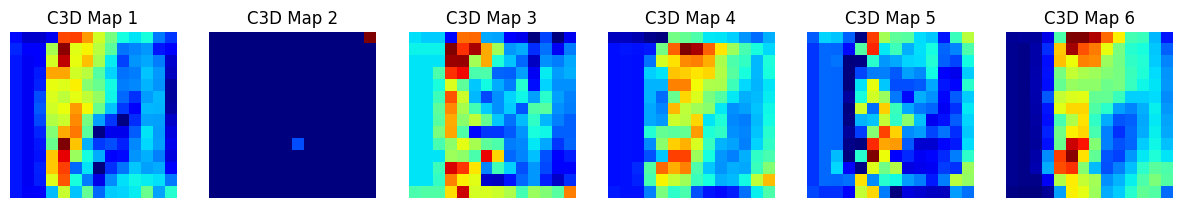

In [16]:
# C3D
# Chọn một frame nhất định trong video clip (ví dụ: frame giữa)
t = c3d_feat_map.shape[2] // 2  # Lấy frame giữa

fig, axes = plt.subplots(1, num_channels, figsize=(15, 5))

# Chuyển tensor về numpy
c3d_feat_map = c3d_feat_map.squeeze(0).cpu().detach().numpy()  # (C, T, H, W)

for i in range(num_channels):
    axes[i].imshow(c3d_feat_map[i, t], cmap='jet')  # Lấy frame tại thời điểm t
    axes[i].axis("off")
    axes[i].set_title(f"C3D Map {i+1}")

plt.show()


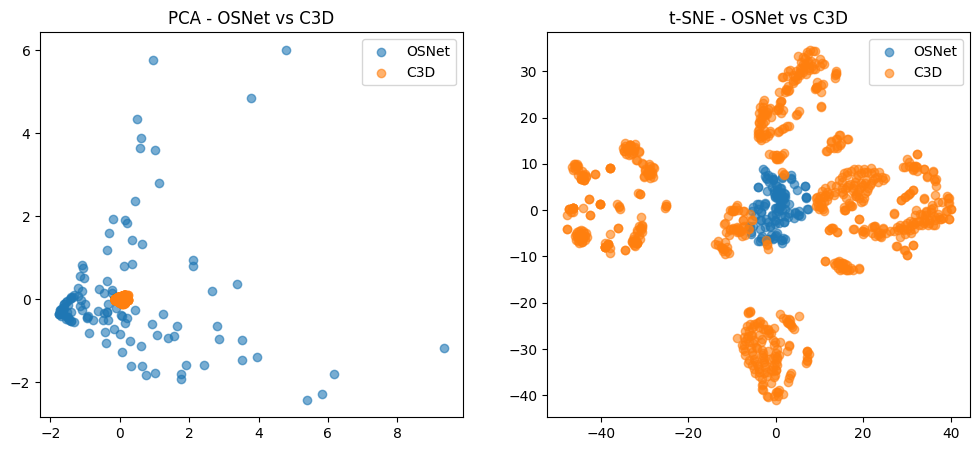

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Chuyển feature map về numpy nếu còn là tensor
if isinstance(osnet_feat_map, torch.Tensor):
    osnet_feat_map = osnet_feat_map.cpu().detach().numpy()
if isinstance(c3d_feat_map, torch.Tensor):
    c3d_feat_map = c3d_feat_map.cpu().detach().numpy()

# Reshape feature map
osnet_feat_flat = osnet_feat_map.reshape(osnet_feat_map.shape[0], -1).T  # (H*W, C1)
c3d_feat_flat = c3d_feat_map.reshape(c3d_feat_map.shape[0], -1).T  # (T*H*W, C2)

# PCA để giảm chiều xuống 2D
pca_osnet = PCA(n_components=2).fit_transform(osnet_feat_flat)
pca_c3d = PCA(n_components=2).fit_transform(c3d_feat_flat)

# t-SNE để xem không gian feature
tsne_osnet = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(osnet_feat_flat)
tsne_c3d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(c3d_feat_flat)

# Vẽ đồ thị
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(pca_osnet[:, 0], pca_osnet[:, 1], label="OSNet", alpha=0.6)
axes[0].scatter(pca_c3d[:, 0], pca_c3d[:, 1], label="C3D", alpha=0.6)
axes[0].set_title("PCA - OSNet vs C3D")
axes[0].legend()

axes[1].scatter(tsne_osnet[:, 0], tsne_osnet[:, 1], label="OSNet", alpha=0.6)
axes[1].scatter(tsne_c3d[:, 0], tsne_c3d[:, 1], label="C3D", alpha=0.6)
axes[1].set_title("t-SNE - OSNet vs C3D")
axes[1].legend()

plt.show()


In [19]:
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

# Chuyển feature vector cuối cùng về numpy
print("Feature Vector Shape:", feature_vector.shape)


if isinstance(feature_vector, torch.Tensor):
    feature_vector = feature_vector.cpu().detach().numpy()

print("Feature Vector Type:", type(feature_vector))
print("Feature Vector Shape:", feature_vector.shape)

# Giảm số hàng của C3D về 128 bằng cách lấy trung bình
factor = c3d_feat_flat.shape[0] // 128  # = 784 // 128 = 6
c3d_downsampled = c3d_feat_flat[:128 * factor].reshape(128, factor, -1).mean(axis=1)  # (128, 256)

# c3d_downsampled = c3d_feat_flat.reshape(128, -1, c3d_feat_flat.shape[1]).mean(axis=1)

# Kiểm tra kích thước
print("OSNet Shape:", osnet_feat_flat.shape)  # (128, C1)
print("C3D Downsampled Shape:", c3d_downsampled.shape)  # (128, C2)

# Ghép OSNet + C3D
combined_feat_map = np.concatenate((osnet_feat_flat, c3d_downsampled), axis=1)  # (128, C1+C2)

# Feature map sau khi kết hợp OSNet + C3D
# combined_feat_map = np.concatenate((osnet_feat_flat, c3d_feat_flat), axis=1)  # (N, C1+C2)

# Tính trung bình theo chiều không gian để có feature đại diện
osnet_feat_avg = osnet_feat_flat.mean(axis=0)  # (C1,)
c3d_feat_avg = c3d_feat_flat.mean(axis=0)  # (C2,)
combined_feat_avg = combined_feat_map.mean(axis=0)  # (C1+C2,)

# Cosine Similarity
cos_osnet = 1 - cosine(osnet_feat_avg, feature_vector)
cos_c3d = 1 - cosine(c3d_feat_avg, feature_vector)
cos_combined = 1 - cosine(combined_feat_avg, feature_vector)

# Pearson Correlation
pearson_osnet, _ = pearsonr(osnet_feat_avg, feature_vector)
pearson_c3d, _ = pearsonr(c3d_feat_avg, feature_vector)
pearson_combined, _ = pearsonr(combined_feat_avg, feature_vector)

print(f"Cosine Similarity - OSNet vs Feature Vector: {cos_osnet:.4f}")
print(f"Cosine Similarity - C3D vs Feature Vector: {cos_c3d:.4f}")
print(f"Cosine Similarity - Combined vs Feature Vector: {cos_combined:.4f}")

print(f"Pearson Correlation - OSNet vs Feature Vector: {pearson_osnet:.4f}")
print(f"Pearson Correlation - C3D vs Feature Vector: {pearson_c3d:.4f}")
print(f"Pearson Correlation - Combined vs Feature Vector: {pearson_combined:.4f}")


Feature Vector Shape: torch.Size([1, 256])
Feature Vector Type: <class 'numpy.ndarray'>
Feature Vector Shape: (1, 256)
OSNet Shape: (128, 128)
C3D Downsampled Shape: (128, 256)


ValueError: Input vector should be 1-D.

In [25]:
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr

# Flatten feature maps
osnet_feat_flat = osnet_feat_map.squeeze(0).mean(dim=(1, 2)).cpu().detach().numpy()  # (C1,)
c3d_feat_flat = c3d_feat_map.squeeze(0).mean(dim=(1, 2, 3)).cpu().detach().numpy()  # (C2,)
feature_vector = feature_vector.squeeze(0).cpu().detach().numpy()  # (D,)

# Cosine Similarity
cos_osnet = 1 - cosine(osnet_feat_flat, feature_vector)
cos_c3d = 1 - cosine(c3d_feat_flat, feature_vector)

# Pearson Correlation
pearson_osnet, _ = pearsonr(osnet_feat_flat, feature_vector)
pearson_c3d, _ = pearsonr(c3d_feat_flat, feature_vector)

print(f"Cosine Similarity - OSNet vs Feature Vector: {cos_osnet:.4f}")
print(f"Cosine Similarity - C3D vs Feature Vector: {cos_c3d:.4f}")
print(f"Pearson Correlation - OSNet vs Feature Vector: {pearson_osnet:.4f}")
print(f"Pearson Correlation - C3D vs Feature Vector: {pearson_c3d:.4f}")


ValueError: cannot select an axis to squeeze out which has size not equal to one

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA giảm về 2D
pca = PCA(n_components=2)
osnet_pca = pca.fit_transform(osnet_feat_flat)  # (128, 2)
c3d_pca = pca.fit_transform(c3d_downsampled)  # (128, 2)
combined_pca = pca.fit_transform(combined_feat_map)  # (128, 2)

# t-SNE để kiểm tra sự phân tán
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
osnet_tsne = tsne.fit_transform(osnet_feat_flat)
c3d_tsne = tsne.fit_transform(c3d_downsampled)
combined_tsne = tsne.fit_transform(combined_feat_map)

# Vẽ đồ thị PCA
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(osnet_pca[:, 0], osnet_pca[:, 1], label="OSNet", alpha=0.5)
axes[0].scatter(c3d_pca[:, 0], c3d_pca[:, 1], label="C3D", alpha=0.5)
axes[0].scatter(combined_pca[:, 0], combined_pca[:, 1], label="OSNet+C3D", alpha=0.7, marker="x")
axes[0].set_title("PCA - OSNet vs C3D vs Combined")
axes[0].legend()

# Vẽ đồ thị t-SNE
axes[1].scatter(osnet_tsne[:, 0], osnet_tsne[:, 1], label="OSNet", alpha=0.5)
axes[1].scatter(c3d_tsne[:, 0], c3d_tsne[:, 1], label="C3D", alpha=0.5)
axes[1].scatter(combined_tsne[:, 0], combined_tsne[:, 1], label="OSNet+C3D", alpha=0.7, marker="x")
axes[1].set_title("t-SNE - OSNet vs C3D vs Combined")
axes[1].legend()

plt.show()


NameError: name 'c3d_downsampled' is not defined

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# PCA giảm về 2D
pca = PCA(n_components=2)
osnet_pca = pca.fit_transform(osnet_feat_flat)  # (128, 2)
c3d_pca = pca.fit_transform(c3d_downsampled)  # (128, 2)
combined_pca = pca.fit_transform(combined_feat_map)  # (128, 2)

# t-SNE để kiểm tra sự phân tán
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
osnet_tsne = tsne.fit_transform(osnet_feat_flat)
c3d_tsne = tsne.fit_transform(c3d_downsampled)
combined_tsne = tsne.fit_transform(combined_feat_map)

# Vẽ đồ thị PCA
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(osnet_pca[:, 0], osnet_pca[:, 1], label="OSNet", alpha=0.5)
axes[0].scatter(c3d_pca[:, 0], c3d_pca[:, 1], label="C3D", alpha=0.5)
axes[0].scatter(combined_pca[:, 0], combined_pca[:, 1], label="OSNet+C3D", alpha=0.7, marker="x")
axes[0].set_title("PCA - OSNet vs C3D vs Combined")
axes[0].legend()

# Vẽ đồ thị t-SNE
axes[1].scatter(osnet_tsne[:, 0], osnet_tsne[:, 1], label="OSNet", alpha=0.5)
axes[1].scatter(c3d_tsne[:, 0], c3d_tsne[:, 1], label="C3D", alpha=0.5)
axes[1].scatter(combined_tsne[:, 0], combined_tsne[:, 1], label="OSNet+C3D", alpha=0.7, marker="x")
axes[1].set_title("t-SNE - OSNet vs C3D vs Combined")
axes[1].legend()

plt.show()


NameError: name 'c3d_downsampled' is not defined